In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

#jax.config.update('jax_platform_name', 'cpu')

# Set default device to CPU


from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE, VPSDE, BaseSDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical, Uniform
from probjax.utils.odeint import _odeint

/root/miniconda3/envs/probjax/lib/python3.10/site-packages/jax/_src/api_util.py:174: SyntaxWarning: Jitted function has static_argnums=(3, 4), but only accepts 4 positional arguments. This warning will be replaced by an error after 2022-08-20 at the earliest.
  warnings.warn(f"Jitted function has {argnums_name}={argnums}, "


In [2]:
mu0 = jnp.array([0.0])
sigma0 = jnp.array([1.0])
prior = Normal(jnp.zeros((1,)), jnp.ones((1,))) 

# Toy example

$$x_{t+1} = x_t + \theta + \epsilon$$
Let us consider the following Structural Equation Model (SEM):
$$
\begin{align*}
    \theta &\sim \mathcal{N} (0, 1) \\
    x_0 &=  \hat{x}_0 ~~~(\text{Deterministic Initialization}) \\
    x_{t+1} & = x_t + \theta + \epsilon ~~~(\epsilon \sim \mathcal{N} (0, 1)).  \\
\end{align*}
$$

Then we have the posterior distribution of $\theta$ given the observed data $x_{0:T}$:

$$ p(\theta | x_{0:T})  = \mathcal{N}  \Biggr(  \frac{x_{T}- x_0}{T+1}, \Bigr(\frac{1}{\sqrt{T+1}}\Bigl)^2 \Biggl).$$


In [3]:
x_0 = jnp.array([0.0])

def simulator(key, theta, T=10):
    
    keys = jrandom.split(key, T-1)
    
    def scan_fn(x, k):
        x_new =  x + theta + jrandom.normal(k)
        return x_new, x_new
    
    _, x = jax.lax.scan(scan_fn, x_0, keys)
    x = jnp.squeeze(x)
    x = jnp.concatenate([x_0, x], axis=-1)
    return x

def posterior(x_o):
    T = x_o.shape[0] 
    mean_post = (x_o[-1] - x_o[0])/T
    std_post = jnp.sqrt(1/T)
    mean_post = jnp.atleast_1d(mean_post)
    std_post = jnp.atleast_1d(std_post)
    return mean_post, std_post

Text(0.5, 1.0, 'Posterior')

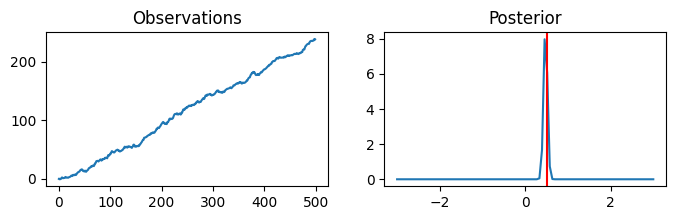

In [250]:
theta_true = 0.5
x_o = simulator(jrandom.PRNGKey(0), theta_true, T=500)
post_mean, post_std = posterior(x_o)
l = jnp.linspace(-3, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(8, 2))
axes[0].plot(x_o)
axes[1].plot(l, jax.scipy.stats.norm.pdf(l, post_mean, post_std))
axes[1].axvline(theta_true, color='r')
axes[0].set_title('Observations')
axes[1].set_title('Posterior')


### Marcov decomposition

Equivalently we can write the posterior distribution of $\theta$ as a Marcov decomposition:

$$ p(\theta | x_{0:T})  =  \prod_{j = 0}^{T-1}p(\theta|x_t, x_{t+1}) \cdot p(\theta)^{-(T-1)} $$
where $p(\theta|x_t, x_{t+1}) = \mathcal{N}(\theta; 0.5 \cdot (x_{t+1} - x_t), \sqrt{0.5})$.

Let's try to verify this result. For this we can use the fact that product of two normal distributions is a normal distribution.

In [251]:
# Some helper functions

def product_of_gaussians(mean1, std1, mean2, std2):
    # Compute the mean and standard deviation of the product of two Gaussians
    mean = (mean1 * std2**2 + mean2 * std1**2) / (std1**2 + std2**2)
    std = jnp.sqrt(1 / (1/std1**2 + 1/std2**2))
    return mean, std

def product_of_n_gaussians(means, stds):
    # Compute the mean and standard deviation of the product of n Gaussians
    mean = jnp.sum(means / stds**2, axis=0) / jnp.sum(1 / stds**2, axis=0)
    std = jnp.sqrt(1 / jnp.sum(1 / stds**2, axis=0))
    return mean, std

def divide_gaussians(mean1, std1, mean2, std2):
    # Divides first Gaussian by the second Gaussian
    mean = (mean1 * std2**2 - mean2 * std1**2) / (std2**2 - std1**2)
    std = jnp.sqrt(1 / (1/std1**2 - 1/std2**2))
    return mean, std

def gaussian_pow(mean, std, n):
    # Compute the mean and standard deviation of the n-th power of a Gaussian
    mean_n = mean**n
    std_n = jnp.abs(n) * mean**(n-1) * std
    return mean_n, std_n


In [252]:
# Version 1
ind_means, ind_std = jax.vmap(posterior)(jnp.vstack([x_o[:-1],x_o[1:]]).T)
means_prior_corr, stds_prior_corr = jax.vmap(divide_gaussians, in_axes=(0,0,None,None))(ind_means, ind_std, mu0, sigma0)
mean_post_corr, std_post_corr = product_of_n_gaussians(means_prior_corr, stds_prior_corr)
mean_post_est, std_post_est = product_of_gaussians(mean_post_corr, std_post_corr, mu0, sigma0)

print(f'Posterior mean: {mean_post_est}, Posterior std: {std_post_est}')
print(f'Reference posterior mean: {post_mean}, Reference posterior std: {post_std}')

Posterior mean: [0.476], Posterior std: [0.045]
Reference posterior mean: [0.476], Reference posterior std: [0.045]


Which mean that in score space we can do the same...

$$ \nabla_{\theta} \log p(\theta | x_{0:T}) = \sum_{j = 0}^{T-1} \nabla_{\theta} \log p(\theta|x_t, x_{t+1}) - (T-1) \nabla_{\theta} \log p(\theta) $$

In [253]:
def posterior_score_fn(x_o):
    mean_post, std_post = posterior(x_o)
    @jax.grad
    def score_fn(theta):
        return jax.scipy.stats.norm.logpdf(theta, mean_post, std_post).sum()
    return score_fn

def posterior_score_fn_decomposed(x_o):
    ind_means, ind_std = jax.vmap(posterior)(jnp.vstack([x_o[:-1],x_o[1:]]).T)
    T = x_o.shape[0]-1
    @jax.grad
    def score_fn_ind(theta):
        return jax.scipy.stats.norm.logpdf(theta, ind_means, ind_std).sum()
    @jax.grad
    def score_fn_prior(theta):
        return jax.scipy.stats.norm.logpdf(theta, mu0, sigma0).sum()
    
    def score_fn(theta):
        scores = score_fn_ind(theta)
        prior_score = score_fn_prior(theta)
        return scores - (T-1) * prior_score
    
    return score_fn



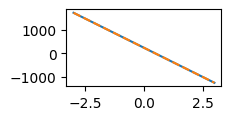

In [254]:
score_fn = posterior_score_fn(x_o)
score_fn_decomposed = posterior_score_fn_decomposed(x_o)
thetas = jnp.linspace(-3, 3, 100)
# Individual scores 
plt.figure(figsize=(2,1))
plt.plot(thetas, jax.vmap(score_fn)(thetas))
plt.plot(thetas, jax.vmap(score_fn_decomposed)(thetas), "--")

### Diffusion process

Now we start a diffusion process over the parameter space $\theta$ i.e. we have a perturbation kernel 
$$ p(\theta_a| \theta) = \mathcal{N}(\theta_a; \mu_a\theta, \sigma^2_a)$$
usually defined through a stochastic differential equation (SDE):
$$ d\theta = f(a)\theta dt + g(a)dW_t$$
where $W_t$ is a Wiener process.

In [255]:
SDE = "VPSDE"

if SDE == "VESDE":
    # VESDE 
    T = 1.
    T_min = 1e-2
    sigma_min = 1e-1
    sigma_max = 10.

    post = Normal(mean_post_est, std_post_est)
    sde = VESDE(post, sigma_min=sigma_min , sigma_max=sigma_max)

else:
    # VPSDE
    T = 1.
    T_min = 1e-2
    beta_min = 1e-1
    beta_max = 10.

    post = Normal(mean_post_est, std_post_est)
    sde = VPSDE(post, beta_min=beta_min , beta_max=beta_max)

a_times = jnp.linspace(T_min, T, 1000)


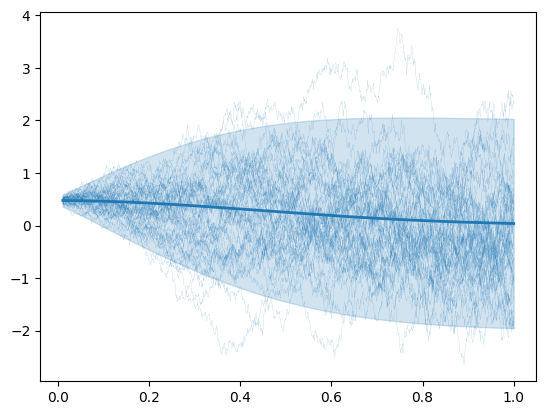

In [256]:
samples = sde.sample(jax.random.PRNGKey(0), a_times, (50,))
mean = sde.mean(a_times)
std = sde.stddev(a_times)

plt.plot(a_times, samples[:,0].T, linestyle="--", color='C0', lw=0.1)
plt.plot(a_times, mean[:,0], color='C0', lw=2)
plt.fill_between(a_times, mean[:,0] - 2*std[:,0], mean[:,0] + 2*std[:,0], color='C0', alpha=0.2)

We can exactly reverse the diffusion if we know the marginal scores of the diffusion process at each time.

As all is Gaussian we can compute the score of the diffusion process at each time, exactly as we did for the posterior distribution of $\theta$.
$$ p(\theta_a|x_{0:T}) = \int p(\theta_a|x_{0:T}, \theta) p(\theta|x_{0:T}) d\theta = \mathcal{N}(\theta_a; \mu_a \mu_p, \mu_a^2\sigma_p^2 + \sigma_a^2)$$
here $\mu_p = \frac{x_{T}- x_0}{T+1}$ and $\sigma_p = \frac{1}{\sqrt{T+1}}$. Hence $\nabla_{\theta_a} \log p(\theta_a|x_{0:T})$ is the score of the diffusion process at each time.

In [257]:
def marginal_posterior(a, x_o):
    mu_p, sigma_p = posterior(x_o)
    mu_a = sde.marginal_mean(a, jnp.array([1.]))
    sigma_a = sde.marginal_stddev(a, jnp.array([1.]))
    mu = mu_a * mu_p
    sigma = jnp.sqrt(mu_a**2 * sigma_p**2 + sigma_a**2)
    return mu, sigma

def marginal_score_fn(a,theta, x_o):
    marginal_mean, marginal_std = marginal_posterior(a, x_o)
    @jax.grad
    def score_fn(theta):
        return jax.scipy.stats.norm.logpdf(theta, marginal_mean, marginal_std).sum()
    
    return score_fn(theta)

def reverse_drift(a, theta):
    a = jnp.atleast_1d(a)
    a = 1-a
    diffusion = sde.diffusion(a,theta)
    drift = sde.drift(a, theta)
    score = marginal_score_fn(a, theta, x_o)
    return -(drift - diffusion**2*score)

def reverse_diffusion(a, theta):
    a = jnp.atleast_1d(a)
    a = 1-a
    return sde.diffusion(a, theta)

noise_dist = Normal(sde.marginal_mean(jnp.array([1.])), sde.marginal_stddev(jnp.array([1.])))
backward_sde = BaseSDE(reverse_drift, reverse_diffusion, noise_dist)

In [258]:
sampels_rev = backward_sde.sample(jax.random.PRNGKey(2), a_times, (50,))
mean_rev = backward_sde.mean(a_times)
std_rev = backward_sde.stddev(a_times)

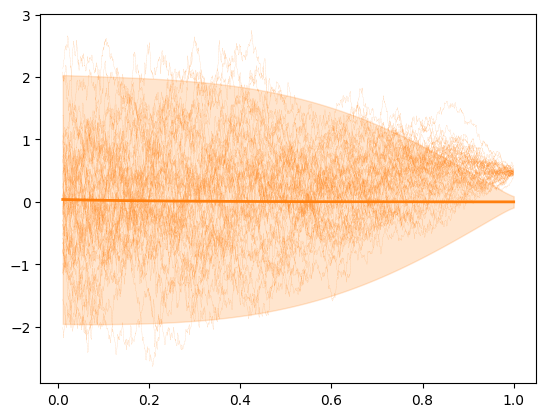

In [259]:
plt.plot(a_times, sampels_rev[:,0].T, linestyle="--", color='C1', lw=0.1)
plt.plot(a_times, mean_rev[:,0], color='C1', lw=2)
plt.fill_between(a_times, mean_rev[:,0] - 2*std_rev[:,0], mean_rev[:,0] + 2*std_rev[:,0], color='C1', alpha=0.2)

### Marcov decomposition of the diffusion process

Yet this would require use to estimate the full conditional score $\nabla_{\theta_a} \log p(\theta_a|x_{0:T})$.

Instead we want to use the Marcov decomposition, such that we only need to estimate the conditional score $\nabla_{\theta_a} \log p(\theta_a|x_t, x_{t+1})$.

The full score is then estimated as:
$$ \nabla_{\theta_a} \log p(\theta_a|x_{0:T}) = \sum_{j = 0}^{T-1} \nabla_{\theta_a} \log p(\theta_a|x_t, x_{t+1}) - (T-1) \nabla_{\theta_a} \log p(\theta_a) $$

Note that in this case we can exaclty compute $p(\theta_a)$ as it is a Gaussian distribution i.e. 
$$ p(\theta_a) = \mathcal{N}(\theta_a; \mu_a \mu_0, \mu_a^2\sigma_0^2 + \sigma_a^2)$$
where $\mu_0 = 0$ and $\sigma_0 = 1$ in our case.

In [260]:
def posterior_score_fn_decomposed(x_o):
    ind_means, ind_std = jax.vmap(posterior)(jnp.vstack([x_o[:-1],x_o[1:]]).T)
    T = x_o.shape[0]-1
    @jax.grad
    def score_fn_ind(theta):
        return jax.scipy.stats.norm.logpdf(theta, ind_means, ind_std).sum()
    @jax.grad
    def score_fn_prior(theta):
        return jax.scipy.stats.norm.logpdf(theta, mu0, sigma0).sum()
    
    def score_fn(theta):
        scores = score_fn_ind(theta)
        prior_score = score_fn_prior(theta)
        return scores - (T-1) * prior_score
    
    return score_fn

In [261]:
def temper_gaussians(mean, std, a):
    # Compute p(x)^a for a Gaussian
    mean_t = mean*a
    std_t = std*jnp.abs(a)
    return mean_t, std_t

def marginal_prior(a):
    # Marginal prior at a
    marginal_mean = sde.marginal_mean(a, jnp.ones_like(a))
    marginal_std = sde.marginal_stddev(a, jnp.ones_like(a))
    
    return marginal_mean*mu0, jnp.sqrt(marginal_mean**2*sigma0**2 + marginal_std**2)

def marginal_individual_post(a, x_o):
    # Marginal individual posterior at a
    ind_means, ind_std = jax.vmap(posterior)(jnp.vstack([x_o[:-1],x_o[1:]]).T)
    marginal_mean = sde.marginal_mean(a, jnp.ones((1,)))
    marginal_std = sde.marginal_stddev(a, jnp.ones((1,)))
    return marginal_mean*ind_means, jnp.sqrt(marginal_mean**2*ind_std**2 + marginal_std**2)

def marginal_est(a, x_o):
    m_prior, s_prior = marginal_prior(a)
    m_post, s_post = marginal_individual_post(a,x_o)
    m_est, s_est = jax.vmap(divide_gaussians,in_axes=(0,0,None,None))(m_post, s_post, m_prior, s_prior)
    m_est, s_est = product_of_n_gaussians(m_est, s_est)
    m_est, s_est = product_of_gaussians(m_est, s_est, m_prior, s_prior)
    return m_est, s_est

# Score fn for the prior
def marginal_prior_score_fn(a, theta):
    m, s = marginal_prior(a)
    @jax.grad
    def score_fn(theta):
        return jax.scipy.stats.norm.logpdf(theta, m, s).sum()
    
    return score_fn(theta)

def marginal_individual_score_fn(a, theta, x_o):
    m, s = marginal_individual_post(a, x_o)
    @jax.grad
    def score_fn(theta):
        return jax.scipy.stats.norm.logpdf(theta, m, s).sum()
    return score_fn(theta)

def marginal_score_fn(a,theta, x_o):
    m, s = marginal_est(a, x_o)
    @jax.grad
    def score_fn(theta):
        return jax.scipy.stats.norm.logpdf(theta, m, s).sum()
    
    return score_fn(theta)

def marginal_score_fn_est(a,theta, x_o):
    T = x_o.shape[0]-1
    prior_score = marginal_prior_score_fn(a, theta)
    ind_score = marginal_individual_score_fn(a, theta, x_o)
    return ind_score - (T-1) * prior_score

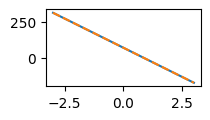

In [262]:
marginal_scores = jax.vmap(marginal_score_fn,in_axes=(None,0, None))(0.5, thetas, x_o)
marginal_scores_est = jax.vmap(marginal_score_fn_est,in_axes=(None,0, None))(0.5, thetas, x_o)

plt.figure(figsize=(2,1))
plt.plot(thetas, marginal_scores)
plt.plot(thetas, marginal_scores_est, "--")

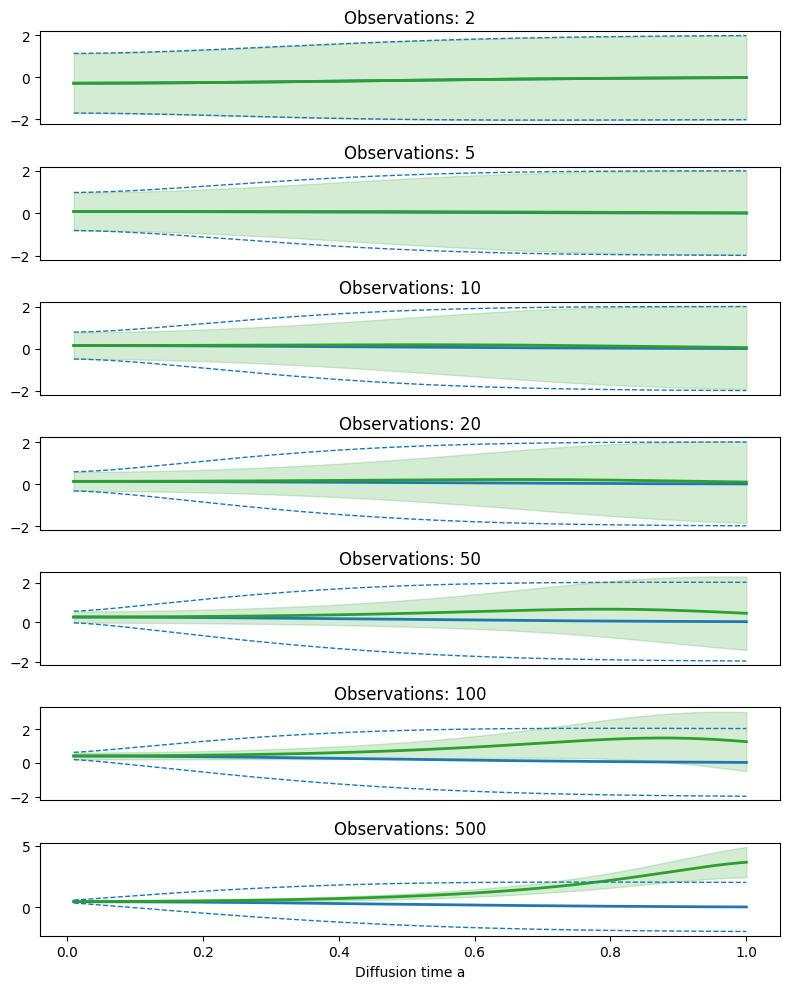

In [263]:
fig, axes = plt.subplots(7,1, figsize=(8, 10))

for i, j in enumerate([2,5, 10, 20, 50, 100, 500]):
    mean, std = jax.vmap(marginal_posterior, in_axes=(0,None))(a_times, x_o[:j])
    means_est, stds_est = jax.vmap(lambda x:marginal_est(x,x_o[:j]))(a_times)
    means_est = means_est.squeeze()
    stds_est = stds_est.squeeze()
    axes[i].plot(a_times, mean, color='C0', lw=2)
    axes[i].plot(a_times, means_est, color='C2', lw=2)
    axes[i].fill_between(a_times, means_est - 2*stds_est, means_est + 2*stds_est, color='C2', alpha=0.2)
    axes[i].plot(a_times, mean - 2*std, color='C0', lw=1, linestyle='--')
    axes[i].plot(a_times, mean + 2*std, color='C0', lw=1, linestyle='--')
    axes[i].set_title(f'Observations: {j}')
    if i < 6:
        axes[i].set_xticks([])
    else:
        axes[i].set_xlabel("Diffusion time a")
        
    

plt.tight_layout()

### Will SDE sampling still work?


In [266]:
def reverse_drift2(a, theta):
    a = jnp.atleast_1d(a)
    a = 1-a
    diffusion = sde.diffusion(a,theta)
    drift = sde.drift(a, theta)
    score = marginal_score_fn_est(a, theta, x_o)
    return -(drift - diffusion**2*score)

def reverse_diffusion2(a, theta):
    a = jnp.atleast_1d(a)
    a = 1-a
    return sde.diffusion(a, theta)

noise_dist2 = Normal(sde.marginal_mean(jnp.array([1.])), sde.marginal_stddev(jnp.array([1.])))
backward_sde2 = BaseSDE(reverse_drift2, reverse_diffusion2, noise_dist)

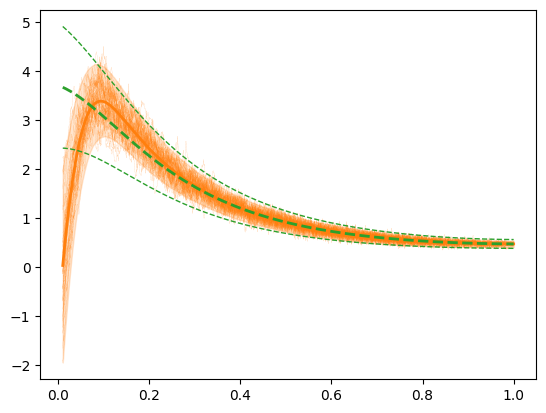

In [267]:

samples2 = backward_sde2.sample(jax.random.PRNGKey(2), a_times, (10000,))
mean2 = samples2.mean(axis=0).T
std2 = samples2.std(axis=0).T

plt.plot(a_times, samples2[:50,0].T, linestyle="--", color='C1', lw=0.1)
plt.plot(a_times, mean2[:,0], color='C1', lw=2)
plt.fill_between(a_times, mean2[:,0] - 2*std2[:,0], mean2[:,0] + 2*std2[:,0], color='C1', alpha=0.2)

plt.plot(a_times, means_est[::-1], color='C2', lw=2, linestyle='--')
plt.plot(a_times, means_est[::-1] - 2*stds_est[::-1], color='C2', lw=1, linestyle='--')
plt.plot(a_times, means_est[::-1] + 2*stds_est[::-1], color='C2', lw=1, linestyle='--')

In [249]:
# Yeah although not in agreement with marginal scores at beginning, it seems to work well at the end.

In [ ]:
# This WILL be a problem for approximating the score function ... 